In [3]:
from pathlib import Path
import os 
from dataclasses import dataclass
import yaml

#from prettyprint 

from tqdm.notebook import tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
import seaborn as sns

import sys
sys.path.append('../../')
sys.path.append('../')

from src import mod_cog_tasks as mct 
from src import mod_cog_data_utils as mcdu
from src import eg_utils
from src import analysis_utils as au
from src import plot_utils as pu

from train_mod_cog import RNNModel

device = eg_utils.get_device()

In [2]:
%load_ext autoreload
%autoreload 2

In [2]:
# ! cp -r  $SCRATCH"/eg_paper/mod_cog/exp8_pruning_cooldown_0715" "/network/projects/_groups/linclab_users/eg/modcog/exp8_pruning_cooldown_0715/"

# Defining folders with experiments 

In [3]:
#results_dir =  Path("/network/projects/_groups/linclab_users/eg/modcog/exp8_pruning_cooldown_0709") 
# results_dir = Path(os.path.join(os.environ['SCRATCH'], "eg_paper/mod_cog/exp8_pruning_cooldown_0715"))
results_dir = Path("/network/projects/_groups/linclab_users/eg/modcog/exp8_pruning_cooldown_0715/")

os.listdir(results_dir)[:10]
#results_dir =  Path("/network/projects/_groups/linclab_users/eg/modcog/exp8_pruning_cooldown_0715") 

['gd_N2500_lr0.75_m0.9_wd1e-06_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss_ff0.99',
 'gd_N2500_lr0.05_m0.9_wd1e-06_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss_ff0.9',
 'gd_N2500_lr0.05_m0.9_wd1e-06_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss_ff0.99',
 'gd_N2500_lr0.05_m0.9_wd1e-06_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss_ff0.925',
 'eg_N2500_lr2.5_m0.9_wd1e-07_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss_ff0.99',
 'eg_N2500_lr0.5_m0.9_wd1e-07_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss_ff0.925',
 'eg_N2500_lr0.75_m0.9_wd1e-07_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss_ff0.925',
 'eg_N2500_lr1.5_m0.925_wd1e-07_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss_ff0.9',
 'gd_N2500_lr0.5_m0.925_wd1e-06_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss_ff0.99',
 'gd_N2500_lr0.25_m0.925_wd1e-06_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss_ff0.975']

In [4]:
! ls "/network/projects/_groups/linclab_users/eg/modcog/"

analysis  data_v2	       exp8_pruning_cooldown_0709  neurogym
data	  exp8_final_combined  exp8_pruning_cooldown_0715


In [5]:
prune_props = [0.9,0.925, 0.95, 0.975, 0.99]
results_dict = {str(pp): {} for pp in prune_props}
for exp_folder in os.listdir(results_dir):
    pp = exp_folder.split("_ff")[-1]
    #print(pp)
    #print(exp_folder.split("_")[3])
    if exp_folder.split("_")[3] != "m0.925":
        continue
    exp_key = "_".join([exp_folder.split("_")[0], exp_folder.split("_")[2],exp_folder.split("_")[3]]) 
    results_dict[pp][exp_key] = au.DotDict({"exp_path": results_dir/exp_folder}) 

In [6]:
results_dict["0.9"]

{'eg_lr1.5_m0.925': {'exp_path': PosixPath('/network/projects/_groups/linclab_users/eg/modcog/exp8_pruning_cooldown_0715/eg_N2500_lr1.5_m0.925_wd1e-07_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss_ff0.9')},
 'gd_lr0.5_m0.925': {'exp_path': PosixPath('/network/projects/_groups/linclab_users/eg/modcog/exp8_pruning_cooldown_0715/gd_N2500_lr0.5_m0.925_wd1e-06_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss_ff0.9')},
 'eg_lr2.5_m0.925': {'exp_path': PosixPath('/network/projects/_groups/linclab_users/eg/modcog/exp8_pruning_cooldown_0715/eg_N2500_lr2.5_m0.925_wd1e-07_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss_ff0.9')},
 'eg_lr2.0_m0.925': {'exp_path': PosixPath('/network/projects/_groups/linclab_users/eg/modcog/exp8_pruning_cooldown_0715/eg_N2500_lr2.0_m0.925_wd1e-07_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss_ff0.9')},
 'eg_lr0.75_m0.925': {'exp_path': PosixPath('/network/projects/_groups/linclab_users/eg/modcog/exp8_pruning_cooldown_0715/eg_N2500_lr0.75_m0.925_wd1

In [7]:
def load_results(results_dict, verbose=True):
    """
    very slightly modified version from au
    """
    # load the results 
    for exp_name in results_dict.keys():
        #print(exp_name, end="")
        found, not_found = 0, 0
        seed_dirs= sorted(os.listdir(results_dict[exp_name]["exp_path"]), key=lambda x: int(x.split("_")[-1]))
        
        for seed_dir in seed_dirs[:]:
            results_dict[exp_name][seed_dir] = au.DotDict({"path": results_dict[exp_name].exp_path/seed_dir})

            # grab checkpoint filepaths
            epoch_ckpts_dir = results_dict[exp_name][seed_dir].path/"epoch_ckpts"
            dec_acc_ckpts_dir = results_dict[exp_name][seed_dir].path/"dec_acc_ckpts"
            results_dict[exp_name][seed_dir].epoch_ckpts = list(epoch_ckpts_dir.glob("*.pt"))
            results_dict[exp_name][seed_dir].dec_acc_ckpts = list(dec_acc_ckpts_dir.glob("*.pt"))

            if len(results_dict[exp_name][seed_dir].dec_acc_ckpts) == 0:
                if verbose: print("No dec_acc_ckpts found")
            else:
                results_dict[exp_name][seed_dir].dec_acc_ckpts = au.sort_dec_acc_checkpoints(results_dict[exp_name][seed_dir].dec_acc_ckpts)
            
            if len(results_dict[exp_name][seed_dir].epoch_ckpts) == 0:
                if verbose: print("No epoch_ckpts found")
            else:
                results_dict[exp_name][seed_dir].epoch_ckpts = au.sort_epoch_checkpoints(results_dict[exp_name][seed_dir].epoch_ckpts)

            # load the train and eval results
            try:
                results_dict[exp_name][seed_dir].train_results = np.load(results_dict[exp_name][seed_dir].path/"train_results.npy", allow_pickle=True)[()]
                results_dict[exp_name][seed_dir].eval_results  = np.load(results_dict[exp_name][seed_dir].path/"eval_results.npy", allow_pickle=True)[()]
                found += 1
            except:
                not_found +=1

            # load the config into a dict
            with open(results_dict[exp_name][seed_dir].path/"config.yaml", 'r') as file:
                # print("Loading config", results_dict[exp_name][seed_dir].path/"config.yaml")
                try:
                    config = au.DotDict(yaml.safe_load(file))
                    results_dict[exp_name][seed_dir].cfg = recursive_dot_dict(config)
                except:
                    pass
                    #print("error loading config", file)

        if verbose: print(f" : loaded {found} results from {found+not_found}")
    return results_dict

results_dict["0.9"] = load_results(results_dict["0.9"], verbose=False)

In [8]:
results_dict["0.9"].keys()

dict_keys(['eg_lr1.5_m0.925', 'gd_lr0.5_m0.925', 'eg_lr2.5_m0.925', 'eg_lr2.0_m0.925', 'eg_lr0.75_m0.925', 'eg_lr0.1_m0.925', 'gd_lr0.01_m0.925', 'eg_lr0.5_m0.925', 'gd_lr0.075_m0.925', 'eg_lr1_m0.925', 'gd_lr0.1_m0.925', 'eg_lr1.25_m0.925', 'gd_lr0.25_m0.925', 'gd_lr0.05_m0.925', 'gd_lr0.75_m0.925'])

In [9]:
for pp in results_dict.keys():
    results_dict[pp] = load_results(results_dict[pp], verbose=False)
    for exp_name in results_dict[pp].keys():
        results_dict[pp][exp_name] = au.concat_seed_results(results_dict[pp][exp_name])
        

In [10]:
results_dict["0.9"]['eg_lr2.5_m0.925'].train_results.keys()

dict_keys(['Loss', 'Loss_auc', 'Mse_fixation', 'Acc', 'Dec Acc', 'Dec_Acc_auc', 'lr', 'grads_norm_before_clip', 'grads_norm_after_clip', 'cos_sim_init_params'])

In [11]:
results_dict["0.9"]['eg_lr2.5_m0.925'].train_results['Dec Acc'].sum(axis=0).mean()

959.6573706924916

In [12]:
results_dict["0.9"]['eg_lr2.5_m0.925'].eval_results.keys()

dict_keys(['val_Acc', 'val_Dec_Acc', 'val_Loss', 'test_Acc', 'test_Dec_Acc', 'test_Loss'])

In [13]:
results_dict["0.9"]['eg_lr2.5_m0.925'].eval_results.val_Dec_Acc.mean(axis=1)[-1]

0.9827038742303849

In [14]:
# need to plot u curves
# get the performance 

In [15]:
# get best results for each eg or gd
from collections import namedtuple

Results = namedtuple("SweepResults", ["key", "perf_metric", "test_dec_acc", "test_acc", "test_Loss"])

#perf_key = 'Dec Acc'
perf_key = "Loss"
best_settings = {}
sweep_summary = {}
for pp in results_dict.keys():
    gd_perfs = []
    eg_perfs = []
    for exp_name in results_dict[pp].keys():
        # assess by sum/auc of training dec acc (more the better)
        #print(results_dict[pp][exp_name].train_results[perf_key].shape)
        perf_metric = results_dict[pp][exp_name].train_results[perf_key].sum(axis=0).mean()
        #perf_metric = results_dict[pp][exp_name].train_results[perf_key][-1,:].mean()

        #print(np.isnan(results_dict[pp][exp_name].train_results[perf_key]).any())
        
        if np.isnan(results_dict[pp][exp_name].train_results[perf_key]).any():
            continue
            
        test_dec_acc = results_dict[pp][exp_name].eval_results.test_Dec_Acc.mean(axis=1)[-1]
        test_acc = results_dict[pp][exp_name].eval_results.test_Acc.mean(axis=1)[-1]
        test_loss = results_dict[pp][exp_name].eval_results.test_Loss.mean(axis=1)[-1]

        r = Results(exp_name,perf_metric,test_dec_acc, test_acc,test_loss )
        if exp_name.startswith("eg"): eg_perfs.append(r)
        else: gd_perfs.append(r)
    
    if perf_key == "Dec Acc":
        sort_reverse = True
    else:
        sort_reverse = False
    gd_perfs = sorted(gd_perfs, key=lambda x: x[1], reverse=sort_reverse)
    eg_perfs = sorted(eg_perfs, key=lambda x: x[1], reverse=sort_reverse)
    
    print(f"{pp} pruned",)
    print(gd_perfs[0])
    print(eg_perfs[0])  
    sweep_summary[pp] = {"eg":eg_perfs, "gd":gd_perfs}
    best_settings[pp] = {"eg":eg_perfs[0],"gd":gd_perfs[0]}

sweep_summary = au.recursive_dot_dict(sweep_summary)
best_settings = au.recursive_dot_dict(best_settings)

0.9 pruned
SweepResults(key='gd_lr0.1_m0.925', perf_metric=785.96556173563, test_dec_acc=0.9792914519309998, test_acc=0.9927197438478469, test_Loss=0.6563732743263244)
SweepResults(key='eg_lr2.0_m0.925', perf_metric=680.9440008878707, test_dec_acc=0.9825986976623534, test_acc=0.9942002791166307, test_Loss=0.6222954342365264)
0.925 pruned
SweepResults(key='gd_lr0.1_m0.925', perf_metric=883.5863579392433, test_dec_acc=0.9729546862840653, test_acc=0.9901885830163956, test_Loss=0.6852320697307587)
SweepResults(key='eg_lr1.5_m0.925', perf_metric=710.5738008618355, test_dec_acc=0.981774328351021, test_acc=0.9938586837053298, test_Loss=0.6269724969863891)
0.95 pruned
SweepResults(key='gd_lr0.25_m0.925', perf_metric=1027.4939219117164, test_dec_acc=0.9527376085519791, test_acc=0.9835174680948258, test_Loss=0.7292029715776444)
SweepResults(key='eg_lr1.5_m0.925', perf_metric=775.0079555988311, test_dec_acc=0.9801158474683762, test_acc=0.9931381472349168, test_Loss=0.6350008379220963)
0.975 prune

In [16]:
sweep_summary["0.9"] = au.recursive_dot_dict(sweep_summary["0.9"])
best_settings["0.9"] = au.recursive_dot_dict(best_settings["0.9"])

In [42]:
def plot_sweep_summary(ss_dict, k):
    """
    verify that the lrs have covered the range of optimal values
    ss_list is the list of results for eg or gd for a given prune prop
    """
    cdict = {"gd":"#5170d7", "eg":"#fd411e"}
    c = cdict[k]
    ss_list = ss_dict[k]
    print(ss_list[0])
    # SweepResults(key='gd_lr0.1_m0.925', perf_metric=785.96556173563, test_dec_acc=0.9792914519309998, test_acc=0.9927197438478469, test_Loss=0.6563732743263244)

    # get diff momentums
    m_list = []
    for ss in ss_list:
        m = ss.key.split("_")[-1]
        if m not in m_list:
            m_list.append(m)
    print(m_list)
    fig, axs = plt.subplots(1, 4, figsize=(8, 2.), dpi=300)

    #ValueError: could not convert string to float: '0.1_m0.925'

    ss_list = sorted(ss_list, key=lambda x: float(x[0].split("lr")[-1].split("_")[0]), reverse=False)
    linestyles = ["-", "--", "-.", ":"]
    for i, m in enumerate(m_list):
        lrs = [float(r[0].split("lr")[-1].split("_")[0]) for r in ss_list if m in r.key]
        
        test_dec_accs = [r.test_dec_acc for r in ss_list if m in r.key]
        test_accs = [r.test_acc for r in ss_list if m in r.key]
        test_Losses =  [r.test_Loss for r in ss_list if m in r.key]
        perf_metrics = [r.perf_metric for r in ss_list if m in r.key]
        
        print(test_dec_accs)
        print(perf_metrics)
        print(lrs)
        
        
        print(axs.shape)
        #axs = [axs[i] for i in range(axs.shape[0])]
        #print(type(axs))
        ms = 3
        axs[0].plot(lrs, perf_metrics, "o-", markersize=ms, c=c, linestyle=linestyles[i])
        axs[0].set_yscale("log")
        axs[0].set_ylabel("Loss auc")
        
        
        axs[1].plot(lrs, test_dec_accs, "o-", markersize=ms, c=c, linestyle=linestyles[i])
        axs[1].set_ylabel("Response\nAccuracy")
        
        axs[2].plot(lrs, test_accs, "o-", markersize=ms, c=c,linestyle=linestyles[i] )
        axs[2].set_ylabel("Accuracy")
        
        axs[3].plot(lrs, test_Losses, "o-", markersize=ms, c=c,linestyle=linestyles[i])
        axs[3].set_ylabel("Final Loss")
    
    fig.suptitle(f"Prune proportion ") # set here for spacing
    for ax in axs:
        ax.set_xlabel("Learning rate")
        #ax.set_xticks(lrs)
        sns.despine(ax=ax)
        
    plt.tight_layout()
    
    return fig

def plot_best_results(eg_key, gd_key, results_dict, gd_c="#5170d7", eg_c="#fd411e", 
                      fig1_size=None, fig2_size=None):
    """
    results is the subdictionary for a given prune prop
    """
    line_alpha=0.2
    
    print(eg_key, results_dict[eg_key].train_results['Dec Acc'].mean(axis=1)[-1])
    print(gd_key, results_dict[gd_key].train_results['Dec Acc'].mean(axis=1)[-1])
    print(results_dict[eg_key].eval_results.keys())
    print(eg_key, results_dict[eg_key].eval_results['test_Dec_Acc'].mean(axis=1)[-1])
    print(gd_key, results_dict[gd_key].eval_results['test_Dec_Acc'].mean(axis=1)[-1])
    
    if fig1_size is None:
        fig1_size = (1.5,1.25)
    fig1 = plt.figure(figsize=fig1_size, dpi = 300)
    
    plt.plot(results_dict[eg_key].train_results['Dec Acc'], c=eg_c, alpha=0.2)
    plt.plot(results_dict[gd_key].train_results['Dec Acc'], c=gd_c, alpha=0.2)
    plt.plot(results_dict[eg_key].train_results['Dec Acc'].mean(axis=1), c=eg_c, alpha=1)
    plt.plot(results_dict[gd_key].train_results['Dec Acc'].mean(axis=1), c=gd_c, alpha=1)
    plt.xlabel("Update #")
    plt.ylabel("Training \nResponse Acc.", rotation=90)
    plt.xlim(0, 1000)
    plt.ylim(0.,1)
    plt.yticks([0,0.5,1])
    sns.despine(offset=2)
    
    
    if fig2_size is None:
        fig2_size = (1.5,1.25)
    fig2 = plt.figure(figsize=fig2_size, dpi = 300)
    
    plt.plot(results_dict[eg_key].train_results['cos_sim_init_params'], c=eg_c, alpha=0.2)
    plt.plot(results_dict[gd_key].train_results['cos_sim_init_params'], c=gd_c, alpha=0.2)
    plt.plot(results_dict[eg_key].train_results['cos_sim_init_params'].mean(axis=1), c=eg_c, alpha=1)
    plt.plot(results_dict[gd_key].train_results['cos_sim_init_params'].mean(axis=1), c=gd_c, alpha=1)
    sns.despine(offset=2)
    plt.xlabel("Update #")
    plt.ylabel("Cosine sim vs \n0-shot pruned", rotation=90)
    plt.xlim(0, 1000)
    plt.ylim(0.9,1)
    plt.yticks([0.9,1])
    
    return fig1, fig2 

eg_lr2.0_m0.925 0.9711953520774841
gd_lr0.1_m0.925 0.9658728837966919
dict_keys(['val_Acc', 'val_Dec_Acc', 'val_Loss', 'test_Acc', 'test_Dec_Acc', 'test_Loss'])
eg_lr2.0_m0.925 0.9825986976623534
gd_lr0.1_m0.925 0.9792914519309998


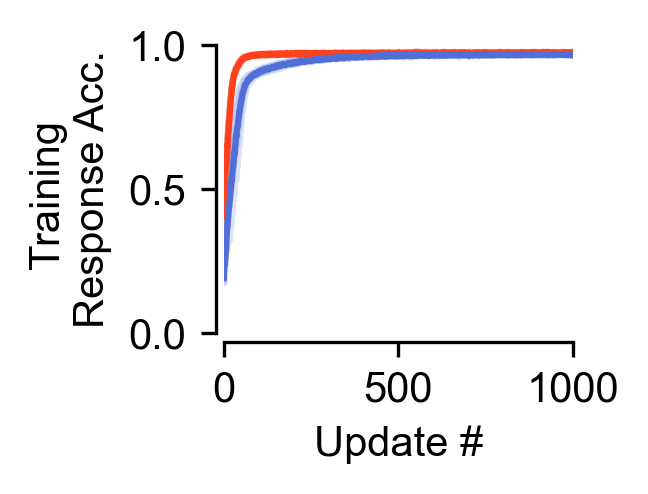

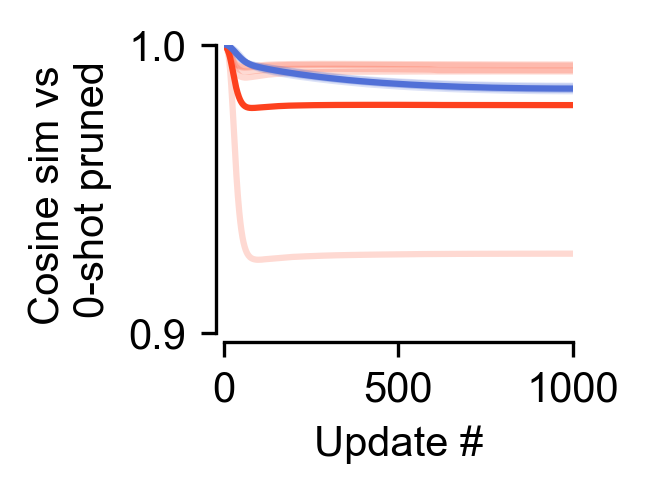

In [43]:
pp = "0.9"
fig1, fig2  = plot_best_results(best_settings[pp].eg[0], best_settings[pp].gd[0], results_dict[pp])

fig1.savefig(f'figs/fig2/{pp}_acc.pdf', dpi=300, transparent=True)
fig2.savefig(f'figs/fig2/{pp}_cos_sim.pdf', dpi=300,transparent=True)

SweepResults(key='gd_lr0.1_m0.925', perf_metric=785.96556173563, test_dec_acc=0.9792914519309998, test_acc=0.9927197438478469, test_Loss=0.6563732743263244)
['m0.925']
[0.9193134460449219, 0.9736173832416535, 0.9776007511615754, 0.9792914519309998, 0.9814361293315887, 0.9794971588850021]
[1105.1692108869552, 841.9072290182114, 805.8415228843689, 785.96556173563, 824.6168005824089, 23960.637498915195]
[0.01, 0.05, 0.075, 0.1, 0.25, 0.5]
(4,)


/tmp/ipykernel_3197644/2856230501.py:42: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  axs[0].plot(lrs, perf_metrics, "o-", markersize=ms, c=c, linestyle=linestyles[i])
/tmp/ipykernel_3197644/2856230501.py:47: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  axs[1].plot(lrs, test_dec_accs, "o-", markersize=ms, c=c, linestyle=linestyles[i])
/tmp/ipykernel_3197644/2856230501.py:50: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  axs[2].plot(lrs, test_accs, "o-", markersize=ms, c=c,linestyle=linestyles[i] )
/tmp/ipykernel_3197644/2856230501.py:53: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argume

Text(0.5, 0.98, 'Prune proportion 0.9')

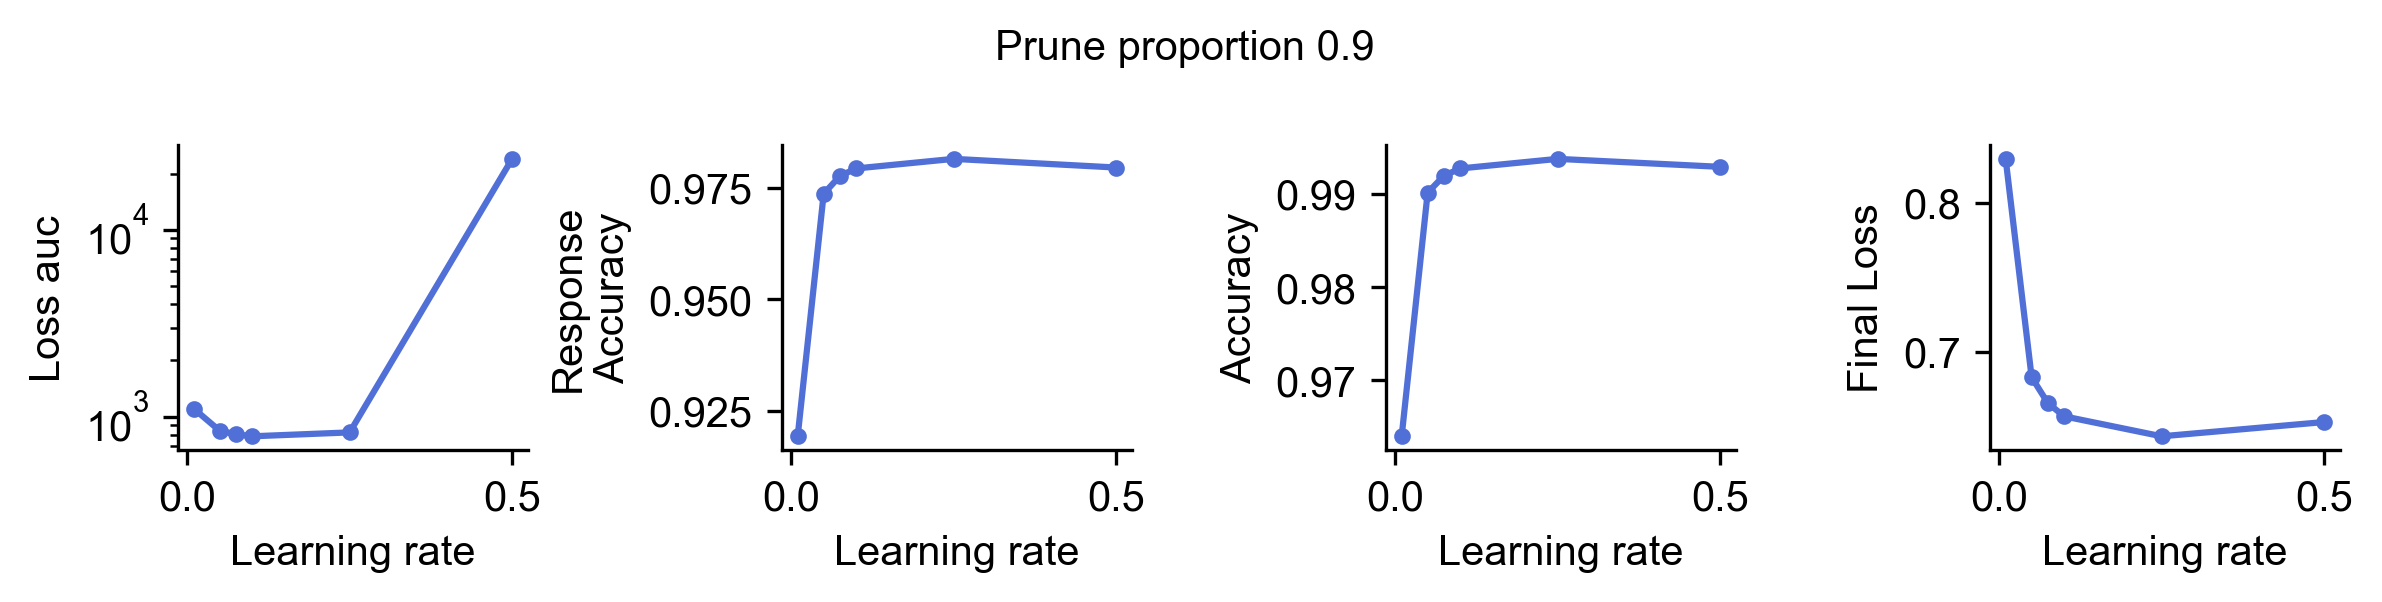

In [44]:
pp = '0.9'
fig = plot_sweep_summary(sweep_summary[pp], "gd")
fig.suptitle(f"Prune proportion {pp}")

SweepResults(key='eg_lr2.0_m0.925', perf_metric=680.9440008878707, test_dec_acc=0.9825986976623534, test_acc=0.9942002791166307, test_Loss=0.6222954342365264)
['m0.925']
[0.9745136556625367, 0.9810992332696916, 0.9817263633012772, 0.98205588555336, 0.9822815331220627, 0.9824493725299834, 0.9825986976623534, 0.9826927305459977]
[819.2252009391784, 709.114815557003, 696.6022589325905, 689.6539831399917, 685.6227303385734, 682.861325454712, 680.9440008878707, 683.1920046567917]
[0.1, 0.5, 0.75, 1.0, 1.25, 1.5, 2.0, 2.5]
(4,)


/tmp/ipykernel_3197644/2856230501.py:42: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  axs[0].plot(lrs, perf_metrics, "o-", markersize=ms, c=c, linestyle=linestyles[i])
/tmp/ipykernel_3197644/2856230501.py:47: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  axs[1].plot(lrs, test_dec_accs, "o-", markersize=ms, c=c, linestyle=linestyles[i])
/tmp/ipykernel_3197644/2856230501.py:50: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  axs[2].plot(lrs, test_accs, "o-", markersize=ms, c=c,linestyle=linestyles[i] )
/tmp/ipykernel_3197644/2856230501.py:53: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argume

Text(0.5, 0.98, 'Prune proportion 0.9')

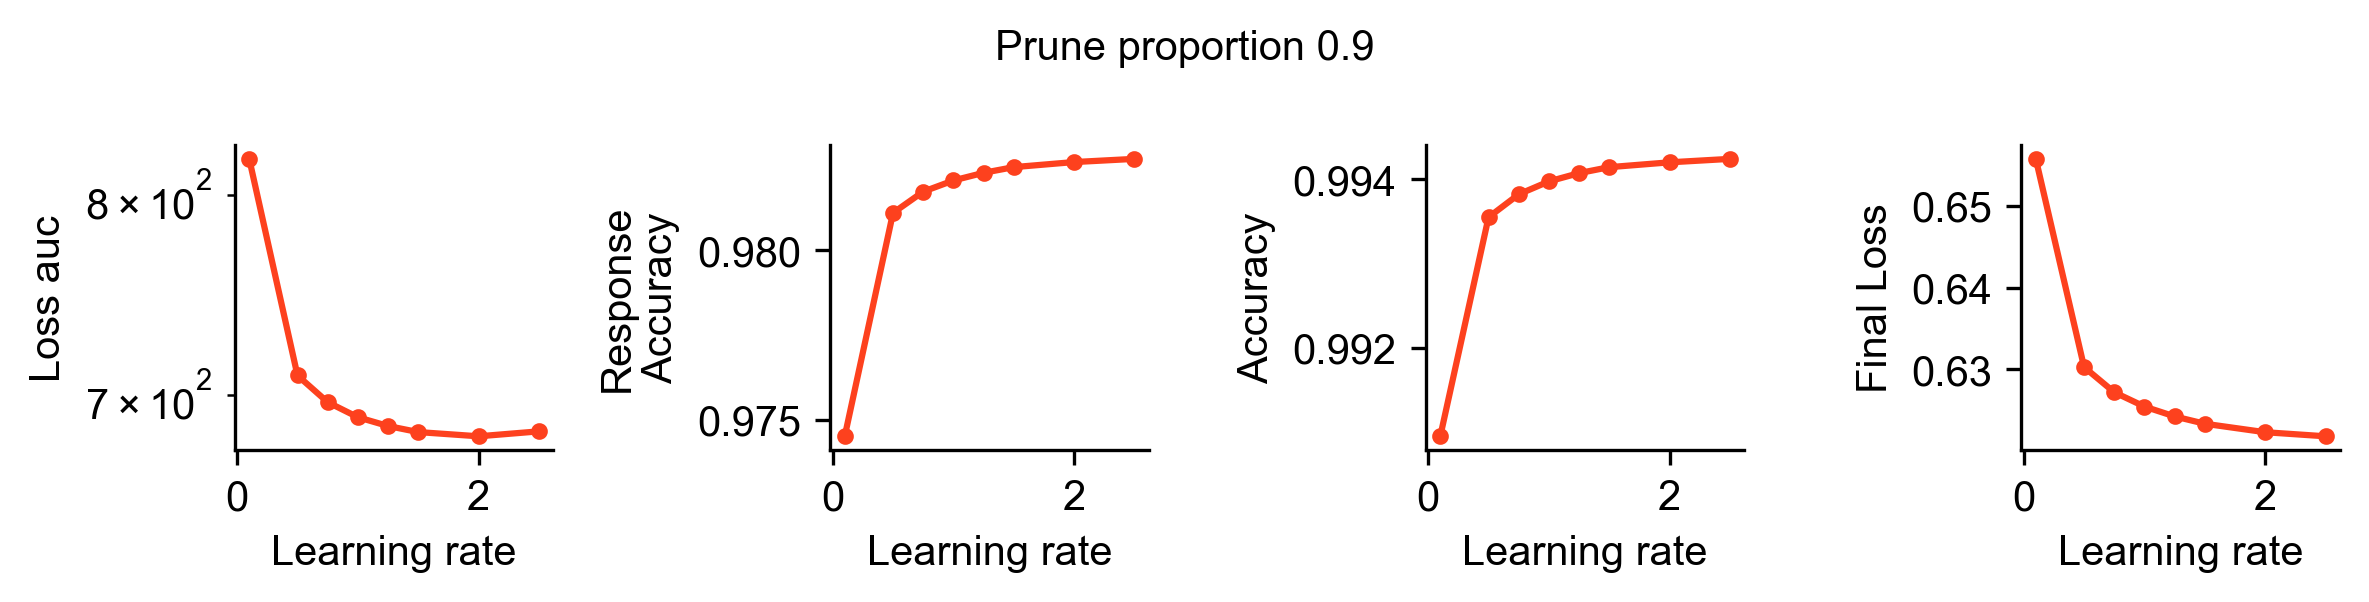

In [45]:
pp = '0.9'
fig = plot_sweep_summary(sweep_summary[pp], "eg")
fig.suptitle(f"Prune proportion {pp}")

eg_lr1.5_m0.925 0.9680988073349
gd_lr0.1_m0.925 0.9556878089904786
dict_keys(['val_Acc', 'val_Dec_Acc', 'val_Loss', 'test_Acc', 'test_Dec_Acc', 'test_Loss'])
eg_lr1.5_m0.925 0.981774328351021
gd_lr0.1_m0.925 0.9729546862840653


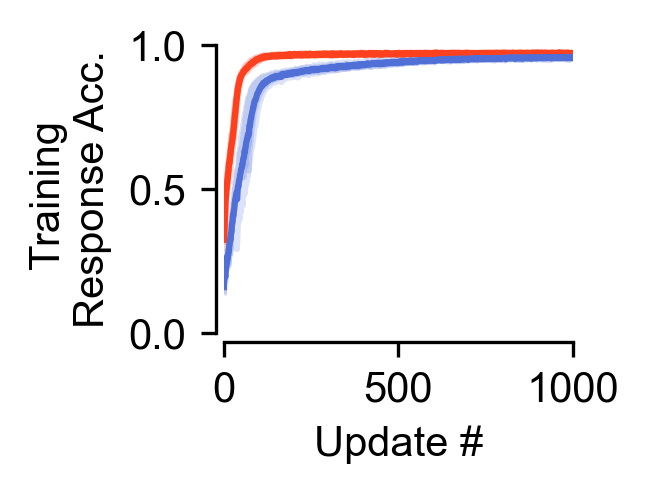

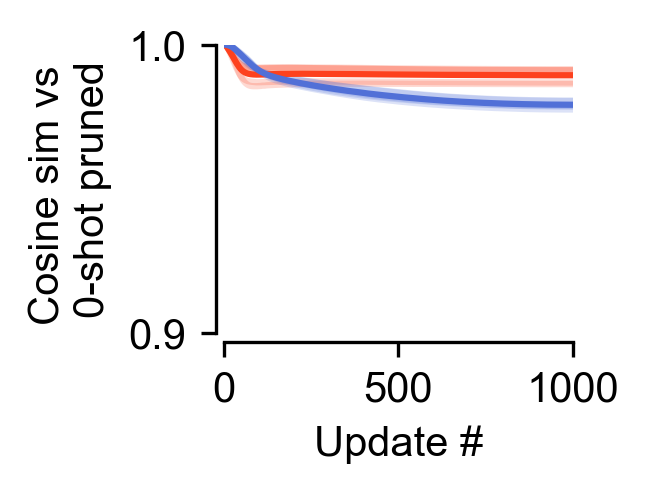

In [46]:
pp = "0.925"
fig1, fig2 = plot_best_results(best_settings[pp].eg[0], best_settings[pp].gd[0], results_dict[pp])
fig1.savefig(f'figs/fig2/{pp}_acc.pdf', dpi=300,transparent=True)
fig2.savefig(f'figs/fig2/{pp}_cos_sim.pdf', dpi=300,transparent=True)

SweepResults(key='gd_lr0.1_m0.925', perf_metric=883.5863579392433, test_dec_acc=0.9729546862840653, test_acc=0.9901885830163956, test_Loss=0.6852320697307587)
['m0.925']
[0.8694131373167039, 0.9479330762624741, 0.9653851897716521, 0.9729546862840653, 0.9782496837377549, 0.9614241499900817, 0.9242005348205566]
[1428.135229599476, 975.6241716623306, 914.2363197445869, 883.5863579392433, 893.4718366265297, 119082.2526876688, 1529.2660124897957]
[0.01, 0.05, 0.075, 0.1, 0.25, 0.5, 0.75]
(4,)
SweepResults(key='eg_lr1.5_m0.925', perf_metric=710.5738008618355, test_dec_acc=0.981774328351021, test_acc=0.9938586837053298, test_Loss=0.6269724969863891)
['m0.925']
[0.9561930916309358, 0.9795320360660552, 0.9806405180692673, 0.9812266354560851, 0.9815630472898483, 0.981774328351021, 0.9820343523025512, 0.9820298454761506]
[988.4739659786225, 758.5688309431076, 735.0789360880851, 722.6379917740821, 714.8705436587334, 710.5738008618355, 24807067.339455973, 713.2656628489494]
[0.1, 0.5, 0.75, 1.0, 1.

/tmp/ipykernel_3197644/2856230501.py:42: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  axs[0].plot(lrs, perf_metrics, "o-", markersize=ms, c=c, linestyle=linestyles[i])
/tmp/ipykernel_3197644/2856230501.py:47: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  axs[1].plot(lrs, test_dec_accs, "o-", markersize=ms, c=c, linestyle=linestyles[i])
/tmp/ipykernel_3197644/2856230501.py:50: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  axs[2].plot(lrs, test_accs, "o-", markersize=ms, c=c,linestyle=linestyles[i] )
/tmp/ipykernel_3197644/2856230501.py:53: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argume

Text(0.5, 0.98, 'Prune proportion 0.925')

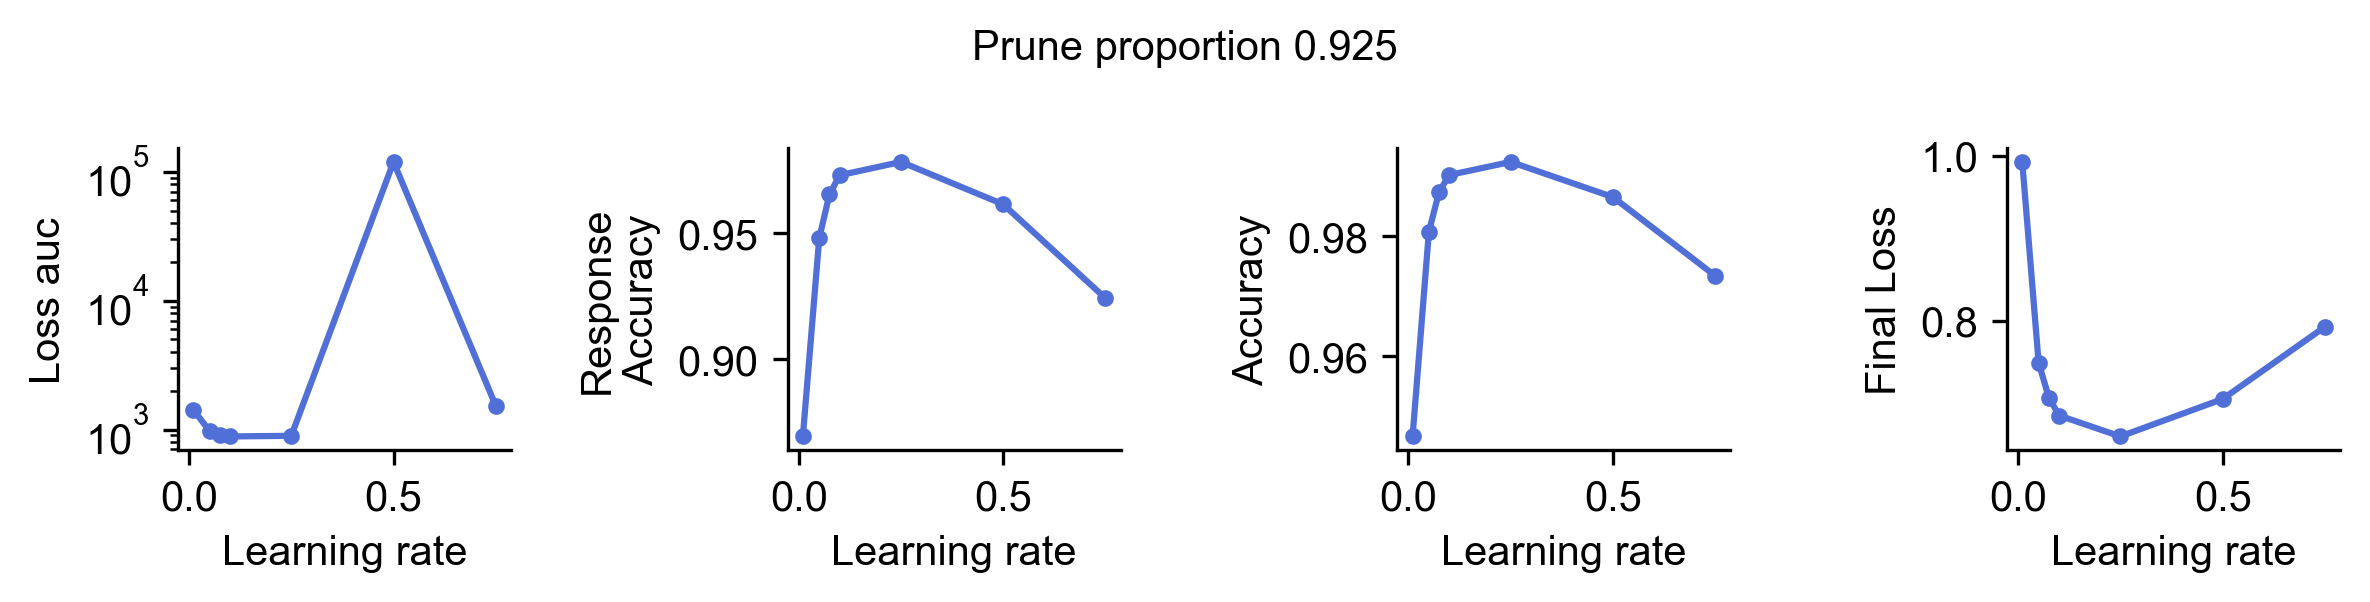

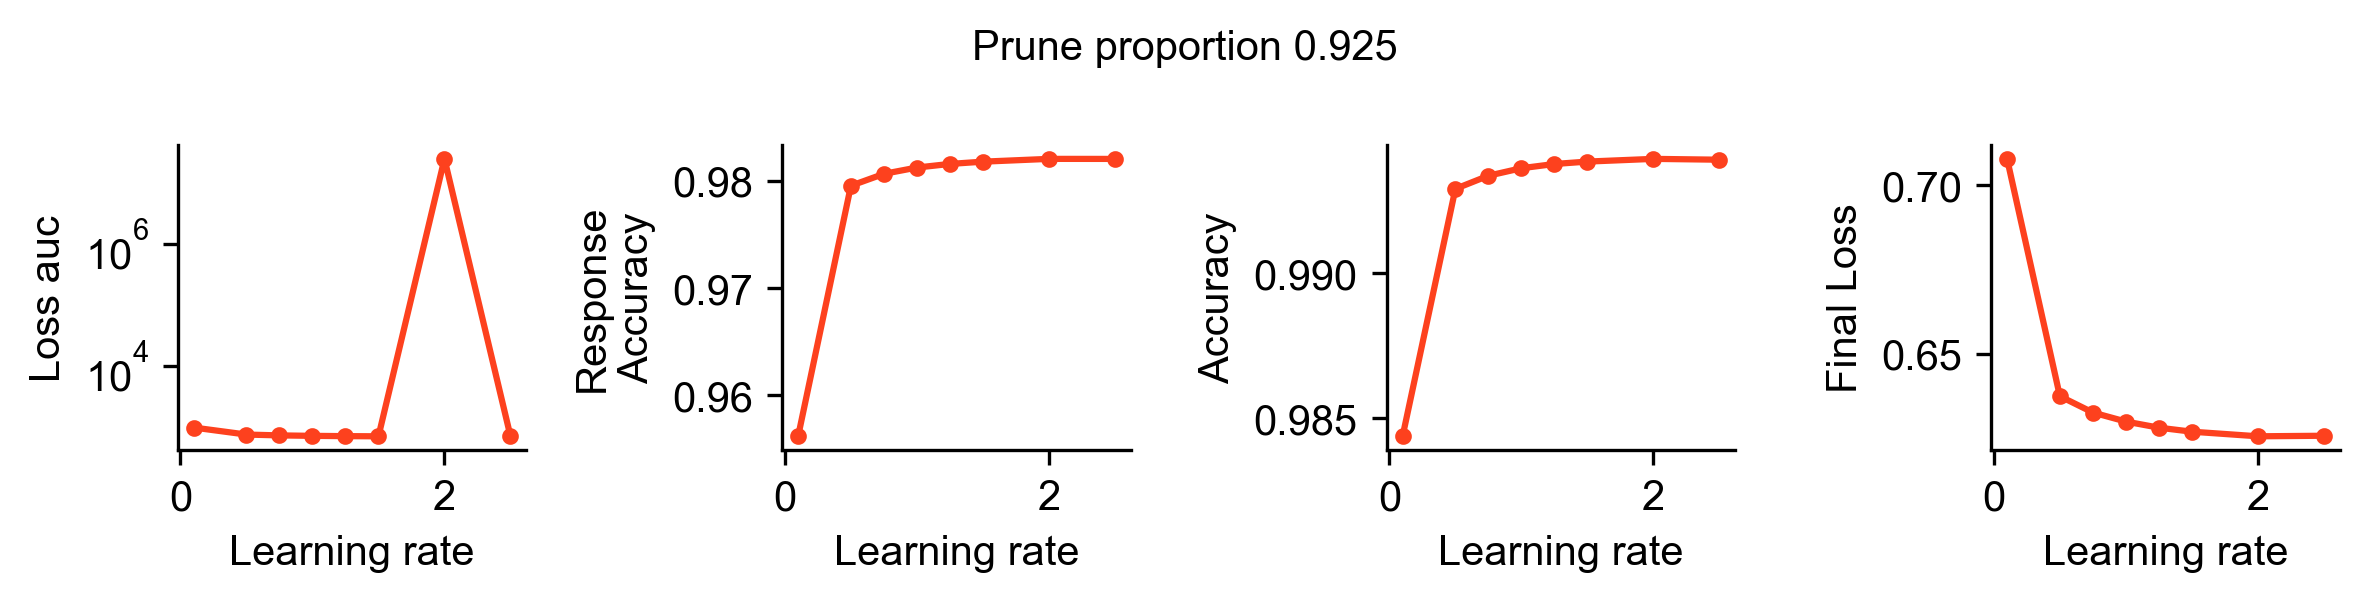

In [47]:
# we don't have the higher lrs due to nans

pp = '0.925'
fig = plot_sweep_summary(sweep_summary[pp], "gd")
fig.suptitle(f"Prune proportion {pp}")

fig = plot_sweep_summary(sweep_summary[pp], "eg")
fig.suptitle(f"Prune proportion {pp}")

eg_lr1.5_m0.925 0.9667355418205261
gd_lr0.25_m0.925 0.9350835084915161
dict_keys(['val_Acc', 'val_Dec_Acc', 'val_Loss', 'test_Acc', 'test_Dec_Acc', 'test_Loss'])
eg_lr1.5_m0.925 0.9801158474683762
gd_lr0.25_m0.925 0.9527376085519791


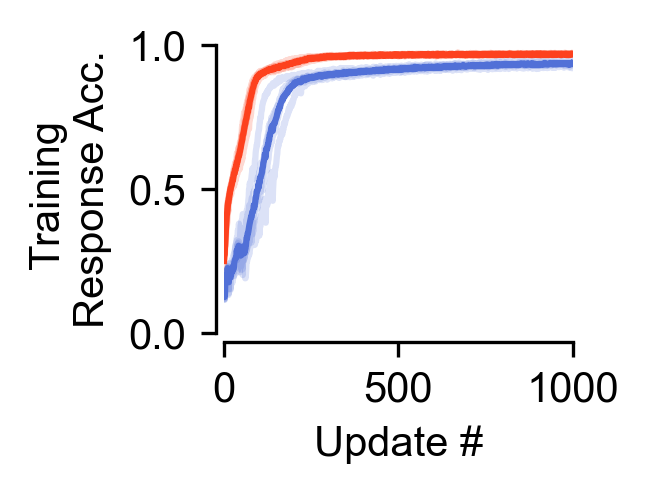

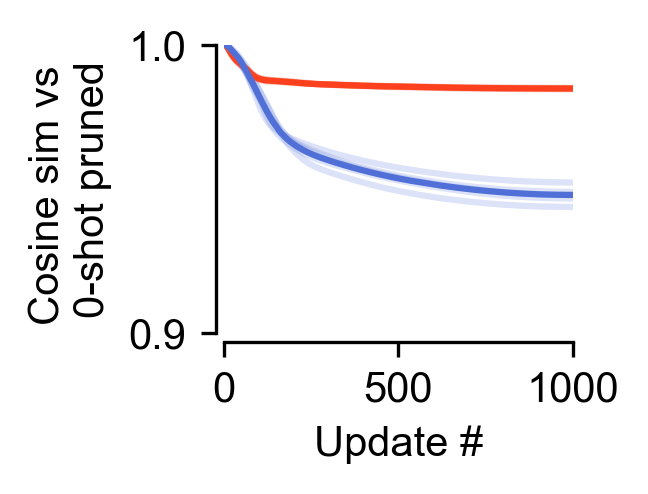

In [48]:
pp = "0.95"
fig1, fig2 = plot_best_results(best_settings[pp].eg[0], best_settings[pp].gd[0], results_dict[pp])

fig1.savefig(f'figs/fig2/{pp}_acc.pdf', dpi=300,transparent=True)
fig2.savefig(f'figs/fig2/{pp}_cos_sim.pdf', dpi=300,transparent=True)

SweepResults(key='gd_lr0.25_m0.925', perf_metric=1027.4939219117164, test_dec_acc=0.9527376085519791, test_acc=0.9835174680948258, test_Loss=0.7292029715776444)
['m0.925']
[0.5635481398105622, 0.9069283068180084, 0.9228995455503464, 0.9341864862442018, 0.9527376085519791, 0.9398332469463349, 0.9104122047424317]
[2149.362879014015, 1249.6641166567802, 1134.2041105031967, 1073.557082772255, 1027.4939219117164, 1206.811698806286, 2002589950276.5325]
[0.01, 0.05, 0.075, 0.1, 0.25, 0.5, 0.75]
(4,)
SweepResults(key='eg_lr1.5_m0.925', perf_metric=775.0079555988311, test_dec_acc=0.9801158474683762, test_acc=0.9931381472349168, test_Loss=0.6350008379220963)
['m0.925']
[0.8352052788734436, 0.971755084514618, 0.9770781548023224, 0.9787253550291062, 0.979558913230896, 0.9801158474683762]
[1424.7351159453392, 895.2094514369965, 835.2990392923355, 804.6520233750343, 1393455968289609.5, 775.0079555988311]
[0.1, 0.5, 0.75, 1.0, 1.25, 1.5]
(4,)


/tmp/ipykernel_3197644/2856230501.py:42: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  axs[0].plot(lrs, perf_metrics, "o-", markersize=ms, c=c, linestyle=linestyles[i])
/tmp/ipykernel_3197644/2856230501.py:47: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  axs[1].plot(lrs, test_dec_accs, "o-", markersize=ms, c=c, linestyle=linestyles[i])
/tmp/ipykernel_3197644/2856230501.py:50: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  axs[2].plot(lrs, test_accs, "o-", markersize=ms, c=c,linestyle=linestyles[i] )
/tmp/ipykernel_3197644/2856230501.py:53: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argume

Text(0.5, 0.98, 'Prune proportion 0.95')

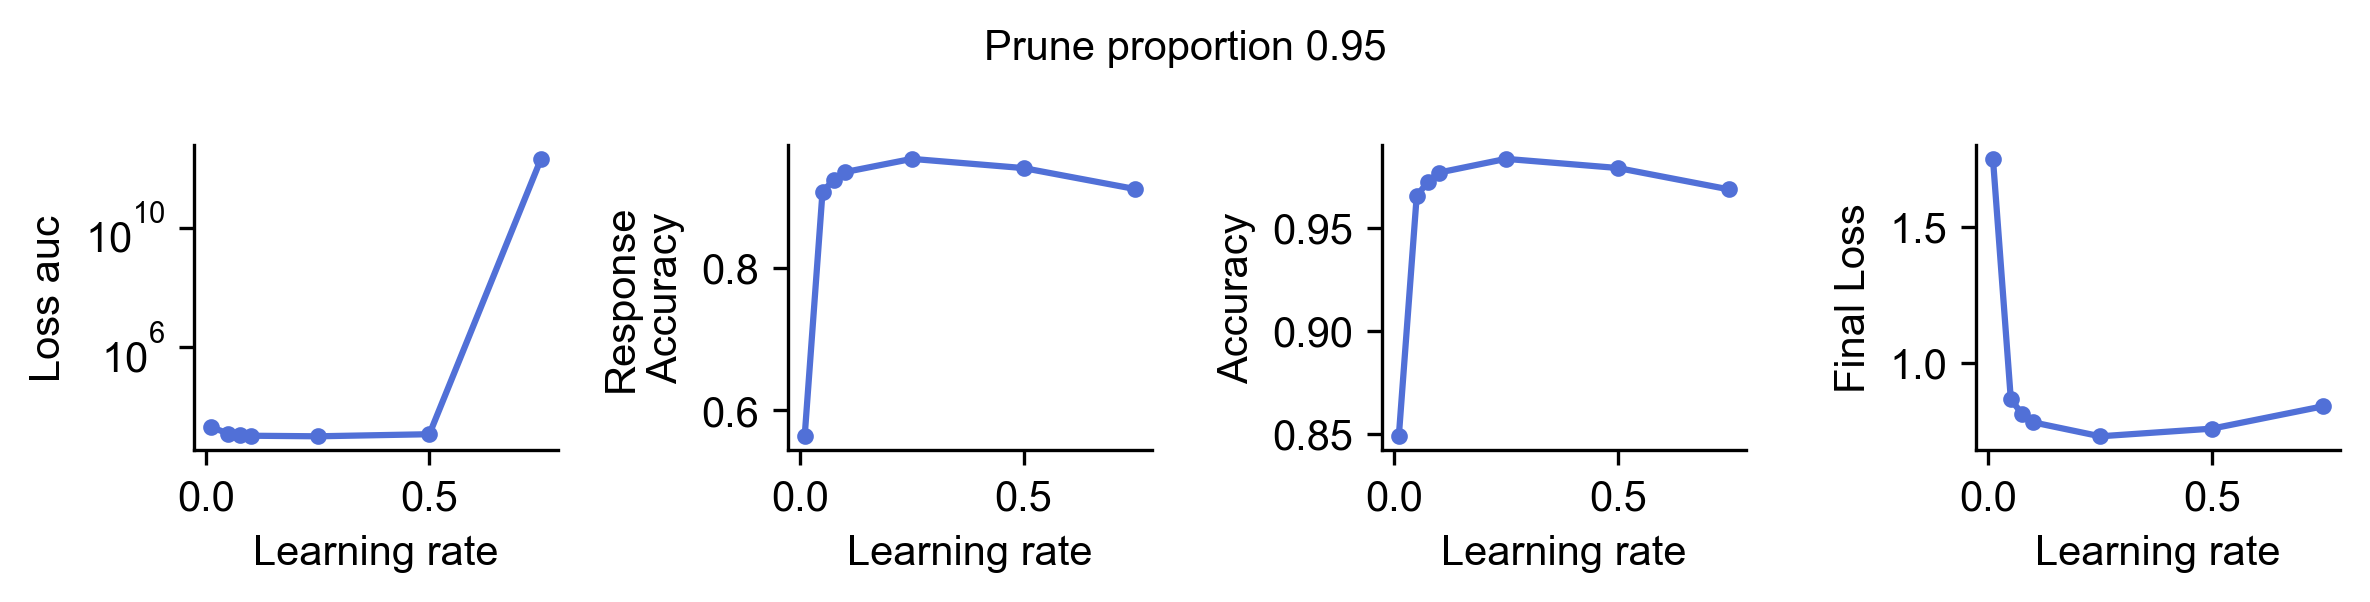

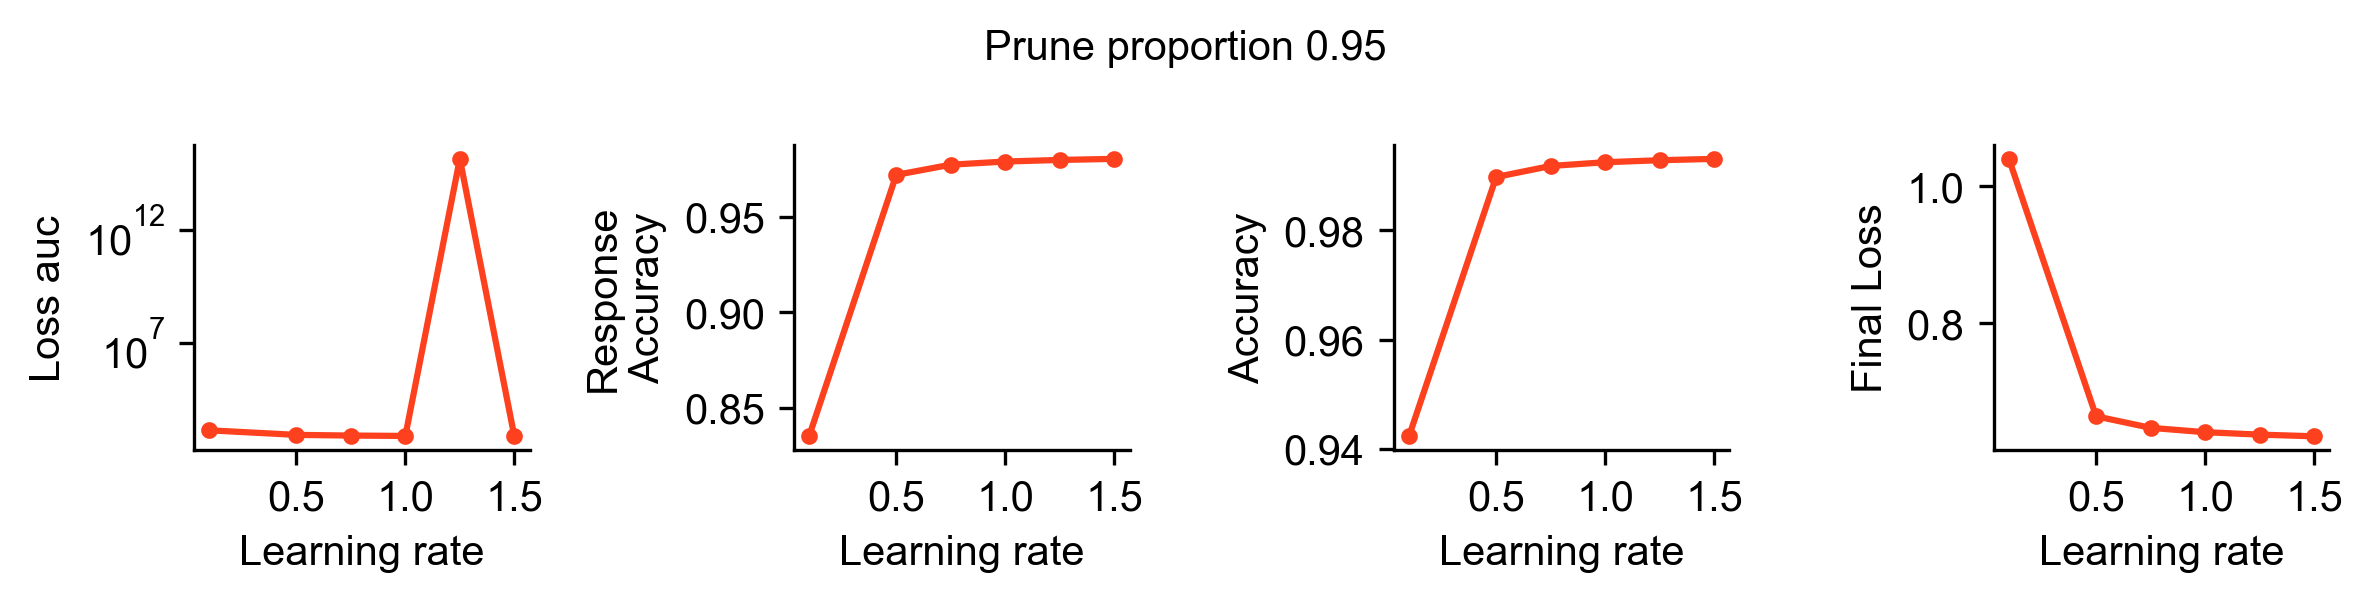

In [52]:
# we don't have the higher lrs due to nans
pp = '0.95'
fig = plot_sweep_summary(sweep_summary[pp], "gd")
fig.suptitle(f"Prune proportion {pp}")

fig = plot_sweep_summary(sweep_summary[pp], "eg")
fig.suptitle(f"Prune proportion {pp}")

eg_lr1.5_m0.925 0.9127864956855773
gd_lr0.25_m0.925 0.8850372791290283
dict_keys(['val_Acc', 'val_Dec_Acc', 'val_Loss', 'test_Acc', 'test_Dec_Acc', 'test_Loss'])
eg_lr1.5_m0.925 0.9318931949138642
gd_lr0.25_m0.925 0.9054159474372863


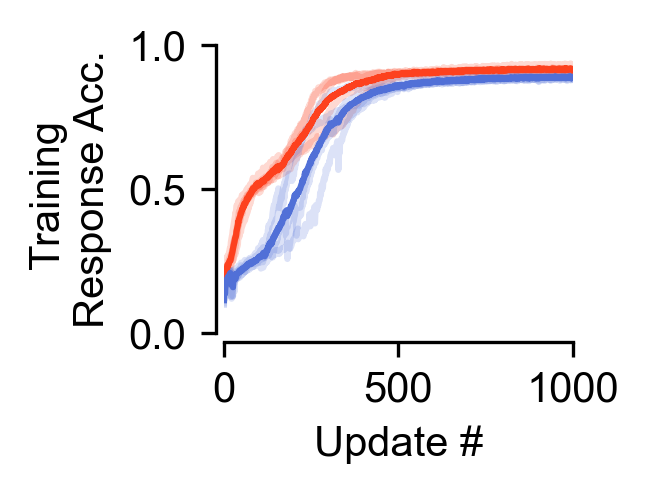

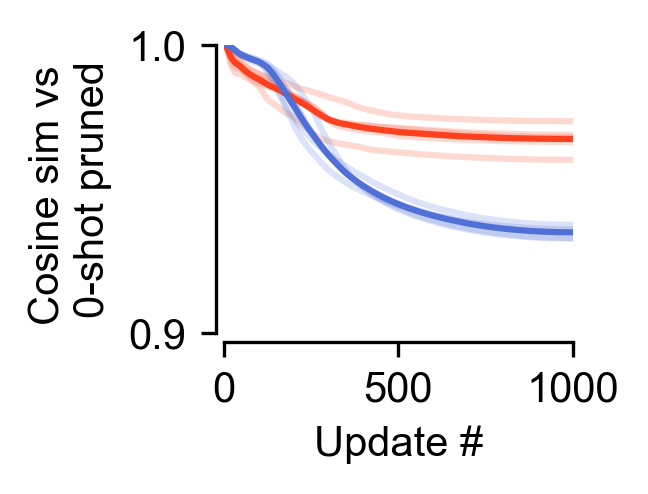

In [53]:
pp = "0.975"
fig1, fig2 = plot_best_results(best_settings[pp].eg[0], best_settings[pp].gd[0], results_dict[pp])
fig1.savefig(f'figs/fig2/{pp}_acc.pdf', dpi=300,transparent=True)
fig2.savefig(f'figs/fig2/{pp}_cos_sim.pdf', dpi=300,transparent=True)

SweepResults(key='gd_lr0.25_m0.925', perf_metric=1350.0233853459358, test_dec_acc=0.9054159474372863, test_acc=0.9672987837791442, test_Loss=0.8598042520284652)
['m0.925']
[0.24647330096364023, 0.5525820204019547, 0.7711819670200348, 0.8484297254085542, 0.9054159474372863]
[2582.084543943405, 2227.791392469406, 1886.5136853456497, 1680.8848937749863, 1350.0233853459358]
[0.01, 0.05, 0.075, 0.1, 0.25]
(4,)
SweepResults(key='eg_lr1.5_m0.925', perf_metric=1106.4491875171661, test_dec_acc=0.9318931949138642, test_acc=0.9766202569007874, test_Loss=0.7602603223323822)
['m0.925']
[0.5573093343973159, 0.8629561321735382, 0.9143808969259262, 0.919960972070694, 0.9252183883190155, 0.9318931949138642]
[1921.0190389871598, 1380.446024978161, 1226.9456444621087, 1152.43114528656, 1122.160895729065, 1106.4491875171661]
[0.1, 0.5, 0.75, 1.0, 1.25, 1.5]
(4,)


/tmp/ipykernel_3197644/2856230501.py:42: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  axs[0].plot(lrs, perf_metrics, "o-", markersize=ms, c=c, linestyle=linestyles[i])
/tmp/ipykernel_3197644/2856230501.py:47: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  axs[1].plot(lrs, test_dec_accs, "o-", markersize=ms, c=c, linestyle=linestyles[i])
/tmp/ipykernel_3197644/2856230501.py:50: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  axs[2].plot(lrs, test_accs, "o-", markersize=ms, c=c,linestyle=linestyles[i] )
/tmp/ipykernel_3197644/2856230501.py:53: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argume

Text(0.5, 0.98, 'Prune proportion 0.975')

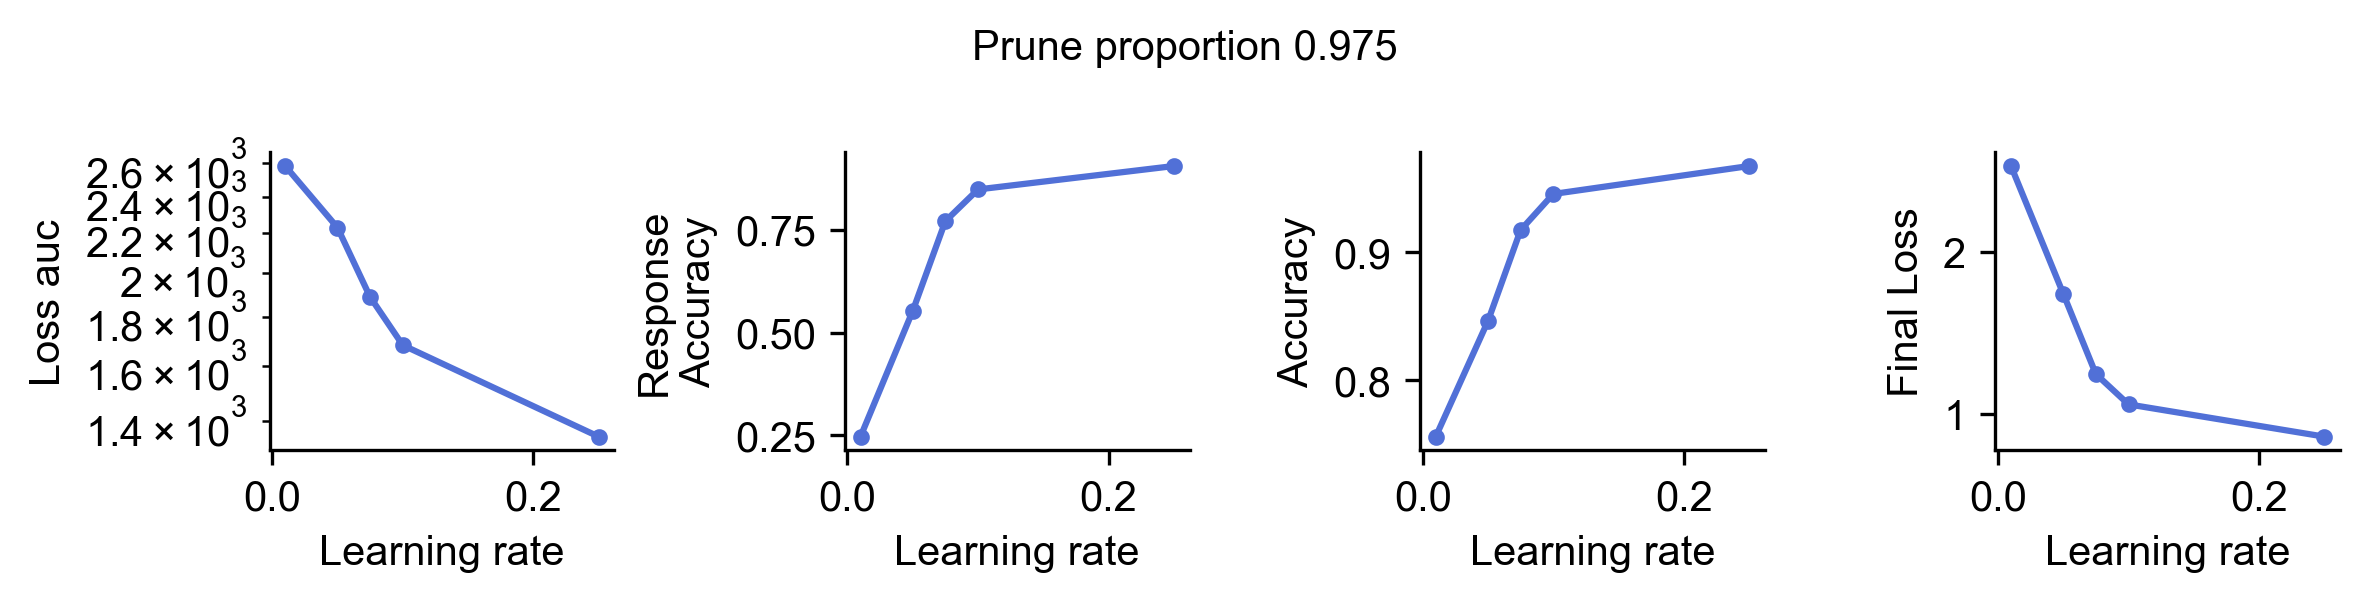

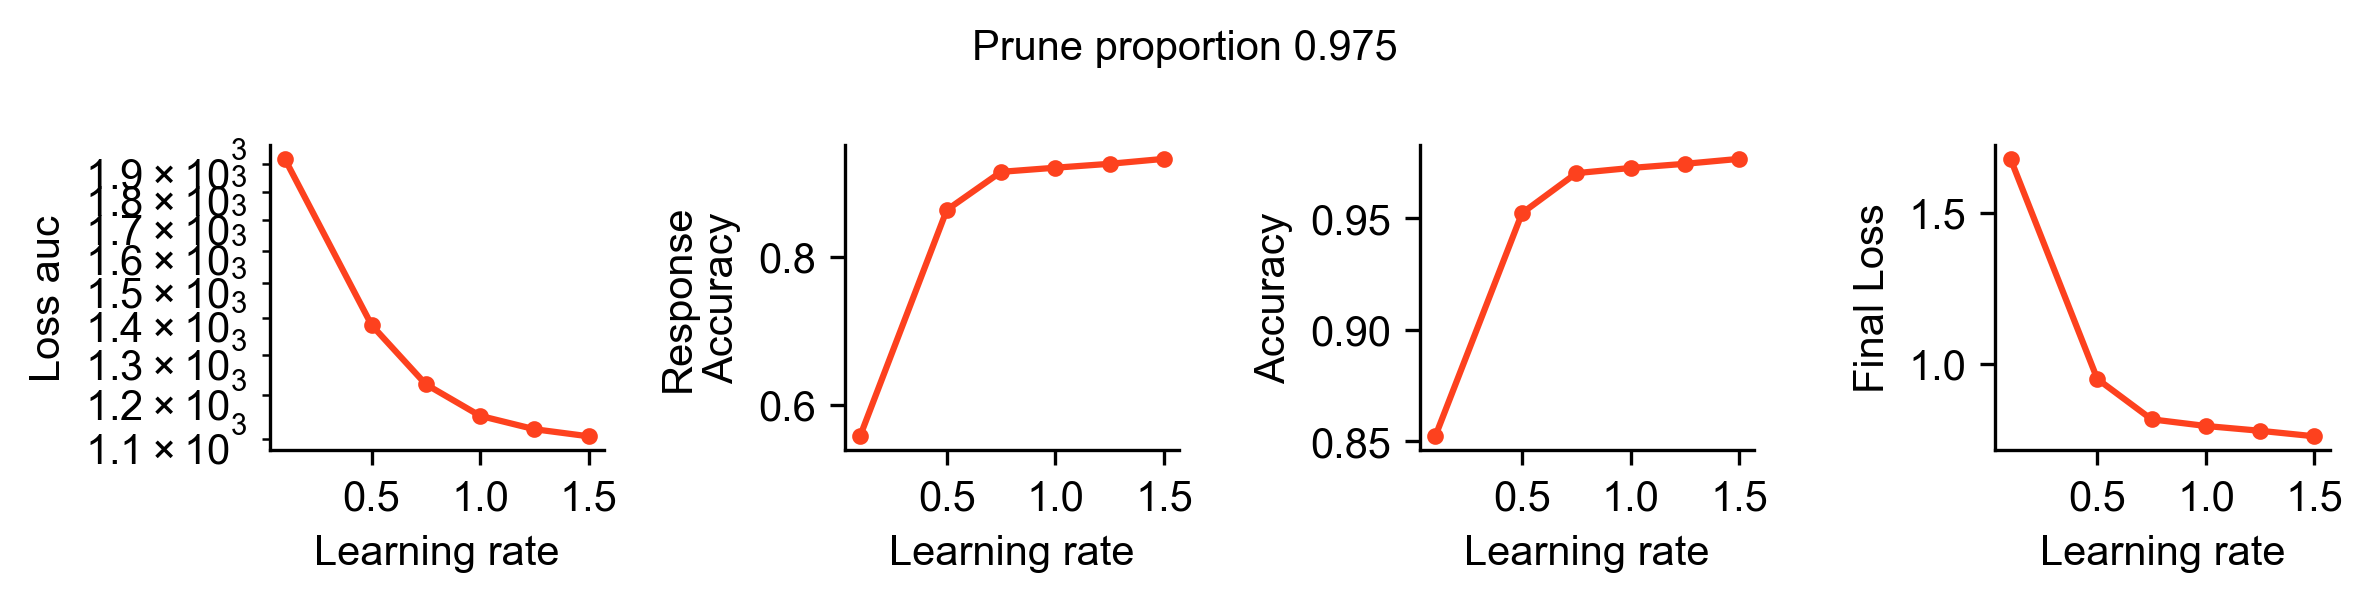

In [54]:
# we don't have the higher lrs due to nans
pp = '0.975'
fig = plot_sweep_summary(sweep_summary[pp], "gd")
fig.suptitle(f"Prune proportion {pp}")

fig = plot_sweep_summary(sweep_summary[pp], "eg")
fig.suptitle(f"Prune proportion {pp}")

eg_lr1_m0.925 0.5956305146217347
gd_lr0.5_m0.925 0.6725620031356812
dict_keys(['val_Acc', 'val_Dec_Acc', 'val_Loss', 'test_Acc', 'test_Dec_Acc', 'test_Loss'])
eg_lr1_m0.925 0.6151293951272965
gd_lr0.5_m0.925 0.7030033714771271


(<Figure size 450x375 with 1 Axes>, <Figure size 450x375 with 1 Axes>)

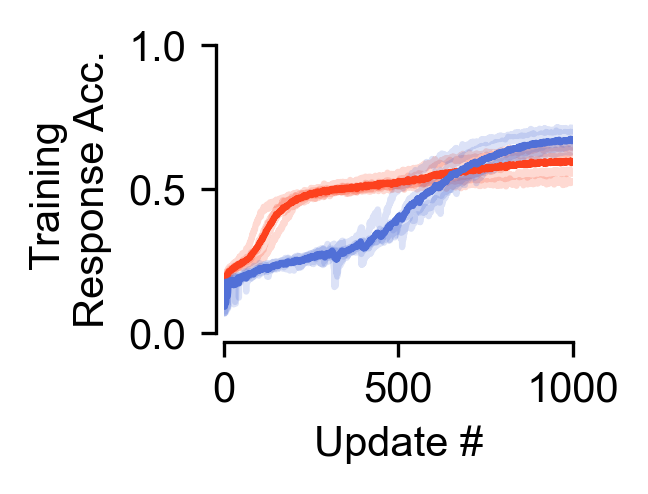

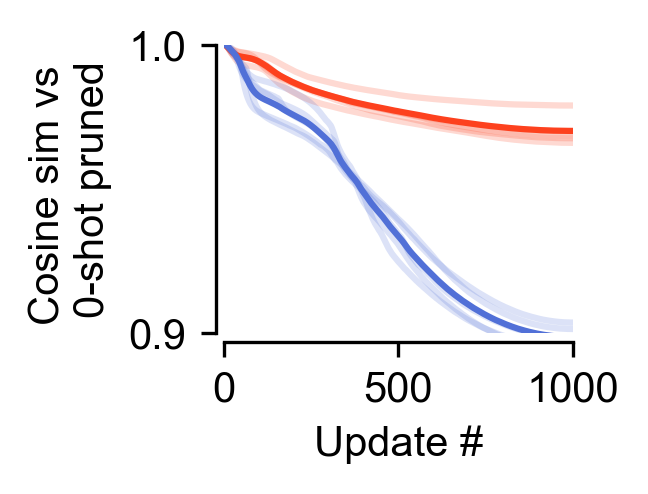

In [55]:
pp = "0.99"
plot_best_results(best_settings[pp].eg[0], best_settings[pp].gd[0], results_dict[pp])

SweepResults(key='gd_lr0.5_m0.925', perf_metric=2076.0048839330675, test_dec_acc=0.7030033714771271, test_acc=0.8968579043149948, test_Loss=1.3931413750648498)
['m0.925']
[0.2079915441274643, 0.24388062229752538, 0.2520855457484722, 0.26740299293398856, 0.6097376566529273, 0.7030033714771271]
[2676.545756483078, 2577.1817861557006, 2558.6722625732423, 2538.9609858512877, 2176.9561713457106, 2076.0048839330675]
[0.01, 0.05, 0.075, 0.1, 0.25, 0.5]
(4,)
SweepResults(key='eg_lr1_m0.925', perf_metric=1814.86461892128, test_dec_acc=0.6151293951272965, test_acc=0.8697441872358322, test_Loss=1.5097032952308653)
['m0.925']
[0.415175263941288, 0.540011415541172, 0.5742393715381623, 0.6151293951272965, 0.6431295768022537]
[2348.6523546218873, 1939.044438123703, 1869.7157361268996, 1814.86461892128, 5133529595774520.0]
[0.1, 0.5, 0.75, 1.0, 1.25]
(4,)


/tmp/ipykernel_3197644/2856230501.py:42: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  axs[0].plot(lrs, perf_metrics, "o-", markersize=ms, c=c, linestyle=linestyles[i])
/tmp/ipykernel_3197644/2856230501.py:47: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  axs[1].plot(lrs, test_dec_accs, "o-", markersize=ms, c=c, linestyle=linestyles[i])
/tmp/ipykernel_3197644/2856230501.py:50: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  axs[2].plot(lrs, test_accs, "o-", markersize=ms, c=c,linestyle=linestyles[i] )
/tmp/ipykernel_3197644/2856230501.py:53: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argume

Text(0.5, 0.98, 'Prune proportion 0.99')

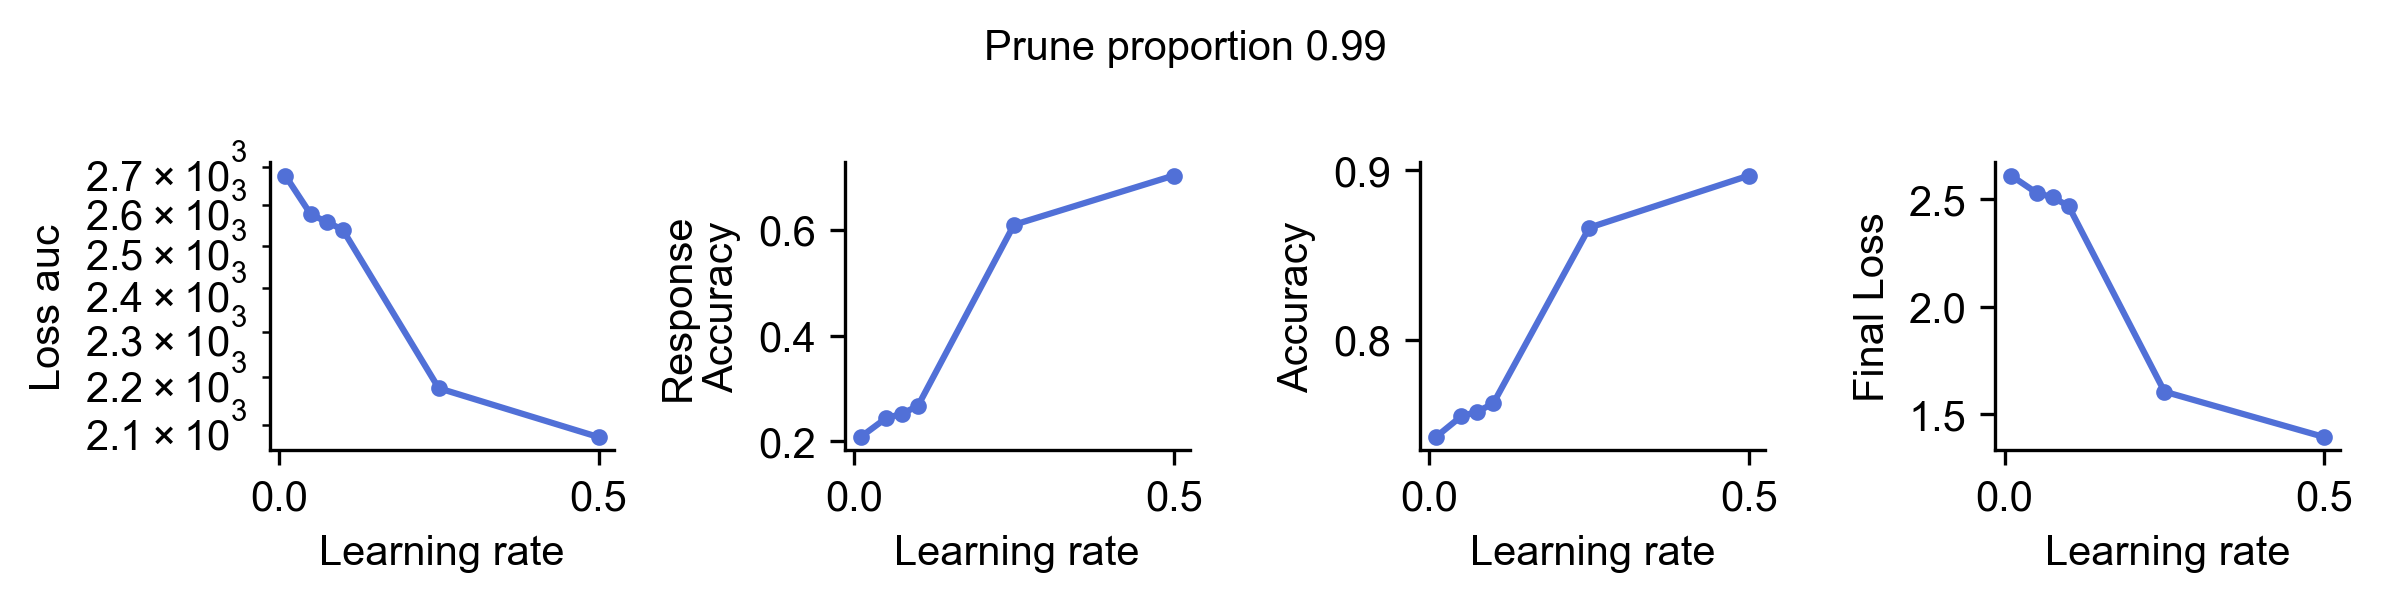

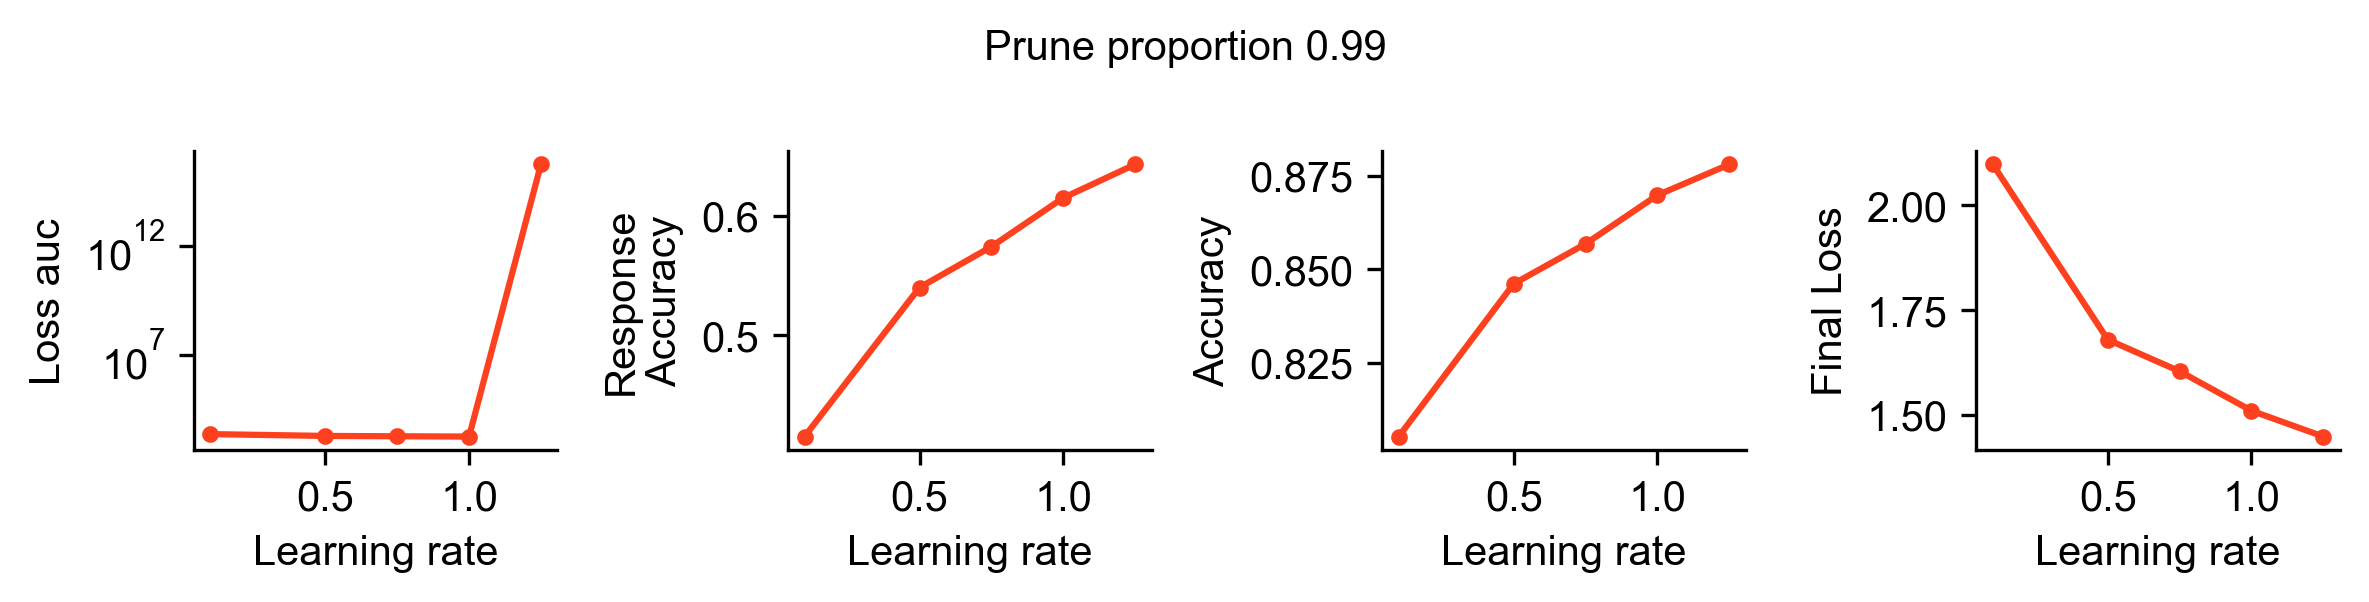

In [56]:
# we don't have the higher lrs due to nans
pp = '0.99'
fig = plot_sweep_summary(sweep_summary[pp], "gd")
fig.suptitle(f"Prune proportion {pp}")

fig = plot_sweep_summary(sweep_summary[pp], "eg")
fig.suptitle(f"Prune proportion {pp}")